# Project: Electric Prediction From Weather


# Project Objectives
* Phân tích mối tương quan giữa các yếu tố thời tiết và mức tiêu thụ điện năng.
* Xây dựng và đánh giá các mô hình Học máy (Machine Learning - ML) để dự đoán nhu cầu điện dựa trên dữ liệu thời tiết thực tế.
* Đề xuất các ứng dụng cho mô hình dự báo trong công tác lập kế hoạch và vận hành hệ thống điện, nhằm giúp tối ưu hóa nguồn lực và giảm thiểu rủi ro thiếu hụt năng lượng trong các giai đoạn thời tiết cực đoan.

## Install and import the required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import time
import logging
import sys
import platform
import sklearn
import io
from os import path
from sklearn.preprocessing import RobustScaler
import psutil, os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Chuẩn bị cấu hình logger để ghi lại quá trình ra file log

In [ ]:
# --- Định nghĩa tên file log ---
LOG_FILE = 'model_training.log'

# --- Xóa file log cũ (nếu có) để bắt đầu một phiên làm việc mới ---
if os.path.exists(LOG_FILE):
    os.remove(LOG_FILE)

# --- Cấu hình Logger ---
logger = logging.getLogger('ML_Project_Logger')
logger.setLevel(logging.INFO)

if logger.hasHandlers():
    logger.handlers.clear()

# 1. Handler để ghi ra file log (dùng mode='a' - append)
file_handler = logging.FileHandler(LOG_FILE, mode='a', encoding='utf-8')
file_handler.setLevel(logging.INFO)
file_formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
file_handler.setFormatter(file_formatter)
logger.addHandler(file_handler)

# 2. Handler để in ra output của Colab/Notebook (giống như print)
stream_handler = logging.StreamHandler(sys.stdout)
stream_handler.setLevel(logging.INFO)
stream_formatter = logging.Formatter('%(message)s') # Chỉ hiện message cho gọn
stream_handler.setFormatter(stream_formatter)
logger.addHandler(stream_handler)

logger.info(f"--- Logger '{logger.name}' đã được khởi tạo. Bắt đầu phiên làm việc. ---")

--- Logger 'ML_Project_Logger' đã được khởi tạo. Bắt đầu phiên làm việc. ---


INFO:ML_Project_Logger:--- Logger 'ML_Project_Logger' đã được khởi tạo. Bắt đầu phiên làm việc. ---


# About The Dataset


*   Thời tiết: NOAA (National Centers for Environmental Information) – sources: https://www.ncei.noaa.gov/
*   Tiêu thụ điện: từ EIA (U.S. Energy Information Administration) – sources:
https://www.eia.gov/opendata/browser/electricity

- Dữ liệu thời tiết: hàng nghìn bản ghi hằng ngày, gồm các biến: Date(Ngày đo), TMAX(Nhiệt độ cao nhất), TMIN(Nhiệt độ thấp nhất), TAVG(Nhiệt độ trung bình), PRCP(Lượng mưa trong ngày), RHAV(Độ ẩm trung bình), CDD(Nhu cầu làm mát), HDD(Nhu cầu sưởi ấm), TEMP_RANGE(Độ lệch nhiệt độ max - min).
- Dữ liệu điện: gồm Date(Ngày), Location(Khu vực), Demand(Nhu cầu tiêu thụ), Net_generation(Sản lượng điện phát ra thực tế), Interchange(Lượng điện trao đổi giữa các vùng).
- Dữ liệu được thu thập ở: Bang California (USA).
- Dữ liệu được thu thập từ ngày: 01/01/2019 đến 31/08/2025

Sau khi lấy dữ liệu từ NOAA và EIA thông qua API key và lưu dữ liệu vào file csv, sau đó load lên github để tiện cho việc lấy dữ liệu sau này nhanh hơn. Dưới đây là cách lấy dữ liệu từ github về để phân tích.

In [ ]:
url_elec = "https://raw.githubusercontent.com/kynpl0406/elec_prediction/refs/heads/main/elec9.csv"
url_weather = "https://raw.githubusercontent.com/kynpl0406/elec_prediction/refs/heads/main/full_data_weather2.csv"


logger.info(f"Đang tải dữ liệu elec từ: {url_elec}")
logger.info(f"Đang tải dữ liệu weather từ: {url_weather}")

try:
    df_elec = pd.read_csv(url_elec)
    df_weather = pd.read_csv(url_weather)

    logger.info("Đã tải dữ liệu thành công!")
    logger.info(f"Shape df_elec ban đầu: {df_elec.shape}")
    logger.info(f"Shape df_weather ban đầu: {df_weather.shape}")

    display(df_elec.head())
    display(df_weather.head())
except Exception as e:
    logger.error(f"Đã xảy ra lỗi khi đọc file: {e}")

Đang tải dữ liệu elec từ: https://raw.githubusercontent.com/kynpl0406/elec_prediction/refs/heads/main/elec9.csv


INFO:ML_Project_Logger:Đang tải dữ liệu elec từ: https://raw.githubusercontent.com/kynpl0406/elec_prediction/refs/heads/main/elec9.csv


Đang tải dữ liệu weather từ: https://raw.githubusercontent.com/kynpl0406/elec_prediction/refs/heads/main/full_data_weather2.csv


INFO:ML_Project_Logger:Đang tải dữ liệu weather từ: https://raw.githubusercontent.com/kynpl0406/elec_prediction/refs/heads/main/full_data_weather2.csv


Đã tải dữ liệu thành công!


...

INFO:ML_Project_Logger:Shape df_elec ban đầu: (2435, 5)


Shape df_weather ban đầu: (12180, 10)


INFO:ML_Project_Logger:Shape df_weather ban đầu: (12180, 10)


,date,location,demand,net_generation,interchange
0,2019-01-01,Pacific,646739,465625,-148563
1,2019-01-02,Pacific,713041,488700,-195461
2,2019-01-03,Pacific,723967,484096,-216036
3,2019-01-04,Pacific,715678,477365,-218420
4,2019-01-05,Pacific,706611,451040,-226354


,date,PRCP,RHAV,TAVG,TMAX,TMIN,station,AWND,CDD,HDD
0,2019-01-01,0.0,18,12.1,16.7,5.0,Los Angeles LAX,2.8,0.0,6.2
1,2019-01-02,0.0,31,11.2,16.1,3.9,Los Angeles LAX,2.1,0.0,7.1
2,2019-01-03,0.0,44,12.4,18.9,7.2,Los Angeles LAX,2.8,0.0,5.9
3,2019-01-04,0.0,52,12.4,17.2,6.7,Los Angeles LAX,2.1,0.0,5.9
4,2019-01-05,14.2,74,12.5,14.4,8.9,Los Angeles LAX,3.4,0.0,5.8


Gộp dữ liệu điện và thời tiết theo ngày

In [ ]:
# Gộp theo ngày
logger.info("Đang gộp (merge) df_elec và df_weather...")
df = pd.merge(df_elec, df_weather, on='date', how='inner')
logger.info(f"Shape sau khi gộp: {df.shape}")
df.head()

Đang gộp (merge) df_elec và df_weather...


INFO:ML_Project_Logger:Đang gộp (merge) df_elec và df_weather...


Shape sau khi gộp: (12175, 14)


INFO:ML_Project_Logger:Shape sau khi gộp: (12175, 14)


,date,location,demand,net_generation,interchange,PRCP,RHAV,TAVG,TMAX,TMIN,station,AWND,CDD,HDD
0,2019-01-01,Pacific,646739,465625,-148563,0.0,18,12.1,16.7,5.0,Los Angeles LAX,2.8,0.0,6.2
1,2019-01-01,Pacific,646739,465625,-148563,0.0,31,11.3,16.1,7.2,San Diego,3.6,0.0,7.0
2,2019-01-01,Pacific,646739,465625,-148563,0.0,41,10.3,12.8,6.7,San Francisco,3.5,0.0,8.0
3,2019-01-01,Pacific,646739,465625,-148563,0.0,48,7.6,12.8,2.8,Sacramento,4.5,0.0,10.7
4,2019-01-01,Pacific,646739,465625,-148563,0.0,81,5.1,10.0,0.6,Fresno,1.4,0.0,13.2


Features Engineering: Dùng kỹ thuật đặc trưng để tách trường dữ liệu ngày thành các yếu tố đặc trưng, giúp mô hình học máy học chính xác hơn.

In [ ]:
# Đảm bảo cột 'date' là kiểu datetime
logger.info("Đang thực hiện feature engineering...")
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['dayofweek'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
logger.info("Tạo features mới hoàn tất (dayofweek, month, is_weekend).")

df.head()

Đang thực hiện feature engineering...


INFO:ML_Project_Logger:Đang thực hiện feature engineering...


Tạo features mới hoàn tất (dayofweek, month, is_weekend).


INFO:ML_Project_Logger:Tạo features mới hoàn tất (dayofweek, month, is_weekend).


,date,location,demand,net_generation,interchange,PRCP,RHAV,TAVG,TMAX,TMIN,station,AWND,CDD,HDD,dayofweek,month,is_weekend
0,2019-01-01,Pacific,646739,465625,-148563,0.0,18,12.1,16.7,5.0,Los Angeles LAX,2.8,0.0,6.2,1,1,0
1,2019-01-01,Pacific,646739,465625,-148563,0.0,31,11.3,16.1,7.2,San Diego,3.6,0.0,7.0,1,1,0
2,2019-01-01,Pacific,646739,465625,-148563,0.0,41,10.3,12.8,6.7,San Francisco,3.5,0.0,8.0,1,1,0
3,2019-01-01,Pacific,646739,465625,-148563,0.0,48,7.6,12.8,2.8,Sacramento,4.5,0.0,10.7,1,1,0
4,2019-01-01,Pacific,646739,465625,-148563,0.0,81,5.1,10.0,0.6,Fresno,1.4,0.0,13.2,1,1,0


# Data Exploration and Descriptive Statistics

In [ ]:
logger.info("--- Bắt đầu Khám phá dữ liệu ---")
logger.info("Đang kiểm tra thông tin (df.info()) của DataFrame đã gộp...")

# Ghi log chi tiết của df.info() vào file
buffer = io.StringIO()
df.info(buf=buffer)
log_info = buffer.getvalue()
logger.info(f"Kết quả df.info():\n{log_info}")

# Hiển thị ra màn hình như bình thường
df.info()

--- Bắt đầu Khám phá dữ liệu ---


INFO:ML_Project_Logger:--- Bắt đầu Khám phá dữ liệu ---


Đang kiểm tra thông tin (df.info()) của DataFrame đã gộp...


INFO:ML_Project_Logger:Đang kiểm tra thông tin (df.info()) của DataFrame đã gộp...


Kết quả df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12175 entries, 0 to 12174
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            12175 non-null  datetime64[ns]
 1   location        12175 non-null  object        
 2   demand          12175 non-null  int64         
 3   net_generation  12175 non-null  int64         
 4   interchange     12175 non-null  int64         
 5   PRCP            12175 non-null  float64       
 6   RHAV            12175 non-null  int64         
 7   TAVG            12175 non-null  float64       
 8   TMAX            12175 non-null  float64       
 9   TMIN            12175 non-null  float64       
 10  station         12175 non-null  object        
 11  AWND            12175 non-null  float64       
 12  CDD             12175 non-null  float64       
 13  HDD             12175 non-null  float64       
 14  dayofweek       12175 non-null  int

INFO:ML_Project_Logger:Kết quả df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12175 entries, 0 to 12174
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            12175 non-null  datetime64[ns]
 1   location        12175 non-null  object        
 2   demand          12175 non-null  int64         
 3   net_generation  12175 non-null  int64         
 4   interchange     12175 non-null  int64         
 5   PRCP            12175 non-null  float64       
 6   RHAV            12175 non-null  int64         
 7   TAVG            12175 non-null  float64       
 8   TMAX            12175 non-null  float64       
 9   TMIN            12175 non-null  float64       
 10  station         12175 non-null  object        
 11  AWND            12175 non-null  float64       
 12  CDD             12175 non-null  float64       
 13  HDD             12175 non-null  float64       
 14  dayofweek   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12175 entries, 0 to 12174
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            12175 non-null  datetime64[ns]
 1   location        12175 non-null  object        
 2   demand          12175 non-null  int64         
 3   net_generation  12175 non-null  int64         
 4   interchange     12175 non-null  int64         
 5   PRCP            12175 non-null  float64       
 6   RHAV            12175 non-null  int64         
 7   TAVG            12175 non-null  float64       
 8   TMAX            12175 non-null  float64       
 9   TMIN            12175 non-null  float64       
 10  station         12175 non-null  object        
 11  AWND            12175 non-null  float64       
 12  CDD             12175 non-null  float64       
 13  HDD             12175 non-null  float64       
 14  dayofweek       12175 non-null  int32         
 15  mo

In [ ]:
logger.info("Đang thực hiện thống kê mô tả (df.describe())...")
df.describe()

Đang thực hiện thống kê mô tả (df.describe())...


INFO:ML_Project_Logger:Đang thực hiện thống kê mô tả (df.describe())...


,date,demand,net_generation,interchange,PRCP,RHAV,TAVG,TMAX,TMIN,AWND,CDD,HDD,dayofweek,month,is_weekend
count,12175,1.217500e+04,12175.000000,12175.000000,12175.000000,12175.00000,12175.000000,12175.000000,12175.000000,12175.000000,12175.000000,12175.000000,12175.000000,12175.000000,12175.000000
mean,2022-05-02 00:00:00,7.360199e+05,573596.964682,-142417.875154,0.947368,64.98694,17.004789,22.643483,12.251441,3.116657,1.634012,2.929248,3.001232,6.322793,0.285832
min,2019-01-01 00:00:00,5.346460e+05,91508.000000,-277749.000000,0.000000,12.00000,2.300000,5.000000,-2.700000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2020-08-31 00:00:00,6.623680e+05,487025.000000,-182399.000000,0.000000,56.00000,13.200000,17.800000,8.900000,2.100000,0.000000,0.000000,1.000000,3.000000,0.000000
50%,2022-05-02 00:00:00,7.029890e+05,557878.000000,-144760.000000,0.000000,68.00000,16.400000,21.100000,12.200000,2.800000,0.000000,1.900000,3.000000,6.000000,0.000000
75%,2024-01-01 00:00:00,7.987610e+05,638207.000000,-105907.000000,0.000000,76.00000,20.200000,26.100000,16.100000,3.800000,1.900000,5.100000,5.000000,9.000000,1.000000
max,2025-08-31 00:00:00,1.191186e+06,973545.000000,12127.000000,137.400000,100.00000,40.400000,45.600000,28.900000,13.500000,22.100000,16.000000,6.000000,12.000000,1.000000
std,NaN,1.081900e+05,118671.449937,52356.007514,4.635721,15.48424,5.486613,6.913333,5.138538,1.592393,3.143031,3.263496,1.999568,3.404828,0.451828


# Data Visualization

Line Chart: Electricity Demand Over Time

Đang tạo biểu đồ Line Plot: Electricity Demand Over Time...


INFO:ML_Project_Logger:Đang tạo biểu đồ Line Plot: Electricity Demand Over Time...


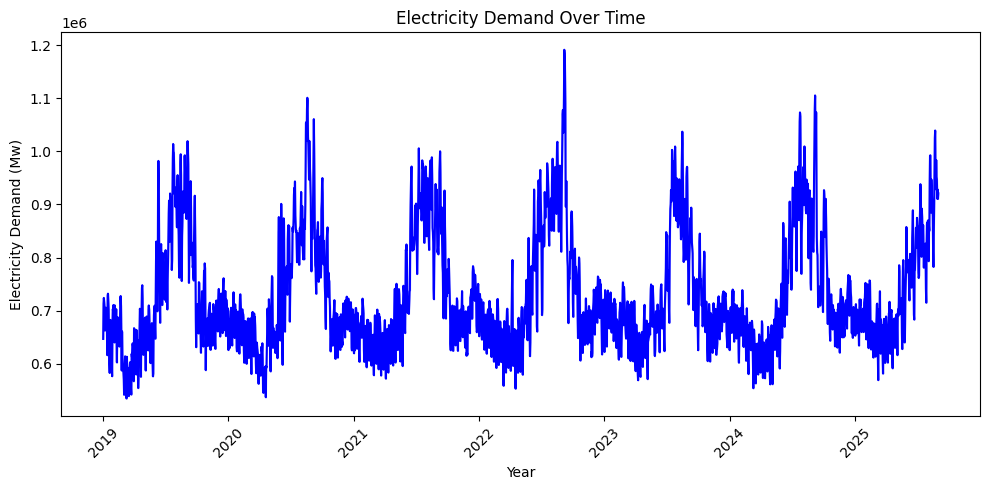

Tạo biểu đồ Line Plot hoàn tất.


INFO:ML_Project_Logger:Tạo biểu đồ Line Plot hoàn tất.


In [ ]:
logger.info("Đang tạo biểu đồ Line Plot: Electricity Demand Over Time...")

df['date'] = pd.to_datetime(df['date'])
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='date', y='demand', color='blue')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title('Electricity Demand Over Time')
plt.xlabel('Year')
plt.ylabel('Electricity Demand (Mw)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

logger.info("Tạo biểu đồ Line Plot hoàn tất.")

Scatter Plot: Temperature vs Electricity Demand

Đang tạo biểu đồ Scatter Plot: Temperature vs Electricity Demand...


INFO:ML_Project_Logger:Đang tạo biểu đồ Scatter Plot: Temperature vs Electricity Demand...


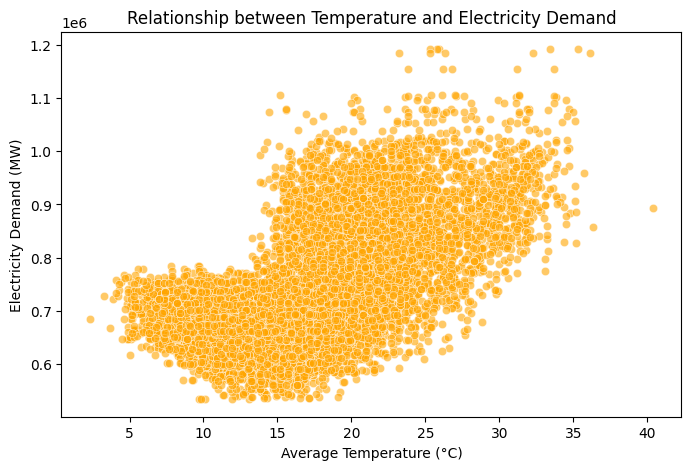

Tạo biểu đồ Scatter Plot hoàn tất.


INFO:ML_Project_Logger:Tạo biểu đồ Scatter Plot hoàn tất.


In [ ]:
logger.info("Đang tạo biểu đồ Scatter Plot: Temperature vs Electricity Demand...")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='TAVG', y='demand', color='orange', alpha=0.6)
plt.title('Relationship between Temperature and Electricity Demand')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Electricity Demand (MW)')
plt.show()

logger.info("Tạo biểu đồ Scatter Plot hoàn tất.")

Heatmap: Correlation between Weather Variables and Demand

Đang tạo biểu đồ Heatmap: Tương quan giữa các biến...


INFO:ML_Project_Logger:Đang tạo biểu đồ Heatmap: Tương quan giữa các biến...


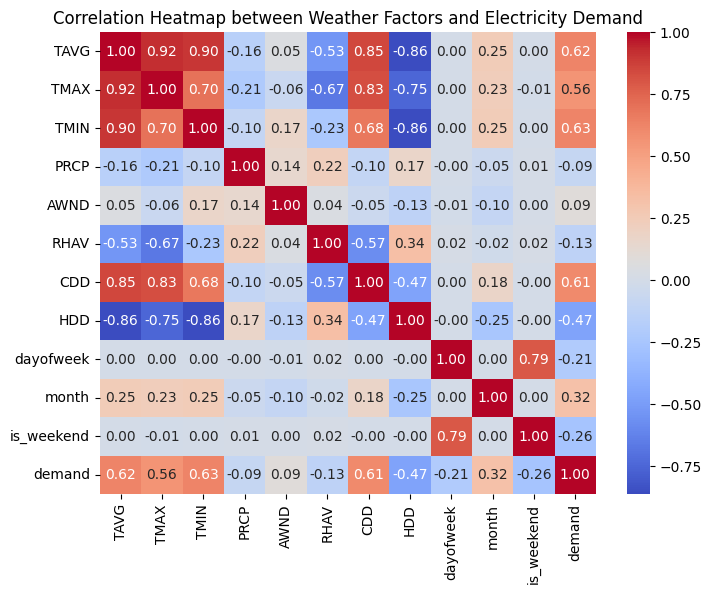

Tạo biểu đồ Heatmap hoàn tất


INFO:ML_Project_Logger:Tạo biểu đồ Heatmap hoàn tất


In [ ]:
logger.info("Đang tạo biểu đồ Heatmap: Tương quan giữa các biến...")

plt.figure(figsize=(8, 6))
sns.heatmap(df[['TAVG', 'TMAX', 'TMIN', 'PRCP', 'AWND', 'RHAV', 'CDD', 'HDD',
                'dayofweek', 'month', 'is_weekend', 'demand']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap between Weather Factors and Electricity Demand')
plt.show()

logger.info("Tạo biểu đồ Heatmap hoàn tất")

Boxplot: Electricity Demand Distribution by Month

Đang tạo biểu đồ Boxplot: Phân phối nhu cầu theo tháng...


INFO:ML_Project_Logger:Đang tạo biểu đồ Boxplot: Phân phối nhu cầu theo tháng...
/tmp/ipython-input-3669441966.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='demand', palette='Set2')


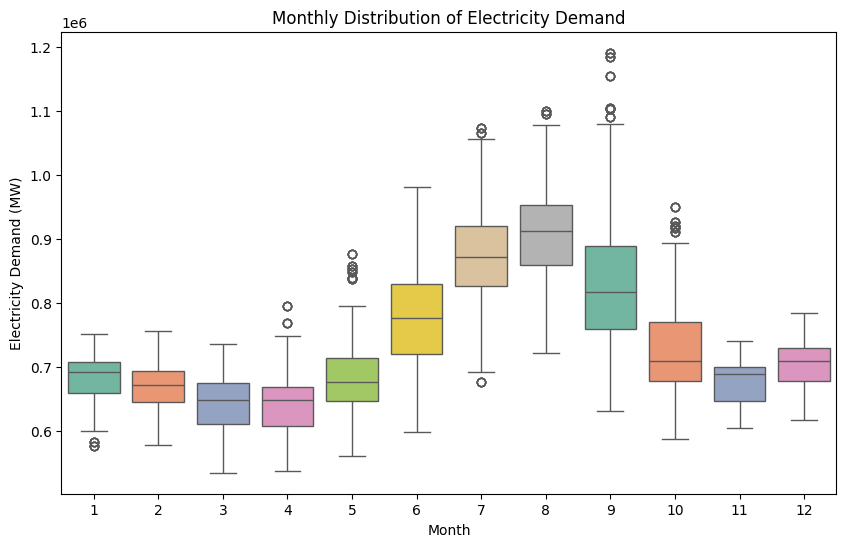

Tạo biểu đồ Boxplot hoàn tất.


INFO:ML_Project_Logger:Tạo biểu đồ Boxplot hoàn tất.


In [ ]:
logger.info("Đang tạo biểu đồ Boxplot: Phân phối nhu cầu theo tháng...")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='month', y='demand', palette='Set2')
plt.title('Monthly Distribution of Electricity Demand')
plt.xlabel('Month')
plt.ylabel('Electricity Demand (MW)')
plt.show()

logger.info("Tạo biểu đồ Boxplot hoàn tất.")

# Data Proccessing

Chọn features và chia dữ liệu train/test

In [ ]:
# Chọn features
features_to_drop = ['date', 'demand', 'location', 'net_generation', 'interchange', 'station']
features = [col for col in df.columns if col not in features_to_drop]
target = 'demand'

logger.info(f"Các features được chọn (X): {features}")
logger.info(f"Biến mục tiêu (y): {target}")

X = df[features]
y = df[target]

# Chia train/test
split_params = {'test_size': 0.2, 'random_state': 42}
logger.info(f"Đang chia train/test với tham số: {split_params}")
X_train, X_test, y_train, y_test = train_test_split(X, y, **split_params)

logger.info(f"Shape X_train: {X_train.shape}, Shape y_train: {y_train.shape}")
logger.info(f"Shape X_test: {X_test.shape}, Shape y_test: {y_test.shape}")

Các features được chọn (X): ['PRCP', 'RHAV', 'TAVG', 'TMAX', 'TMIN', 'AWND', 'CDD', 'HDD', 'dayofweek', 'month', 'is_weekend']


INFO:ML_Project_Logger:Các features được chọn (X): ['PRCP', 'RHAV', 'TAVG', 'TMAX', 'TMIN', 'AWND', 'CDD', 'HDD', 'dayofweek', 'month', 'is_weekend']


Biến mục tiêu (y): demand


INFO:ML_Project_Logger:Biến mục tiêu (y): demand


Đang chia train/test với tham số: {'test_size': 0.2, 'random_state': 42}


INFO:ML_Project_Logger:Đang chia train/test với tham số: {'test_size': 0.2, 'random_state': 42}


Shape X_train: (9740, 11), Shape y_train: (9740,)


INFO:ML_Project_Logger:Shape X_train: (9740, 11), Shape y_train: (9740,)


Shape X_test: (2435, 11), Shape y_test: (2435,)


INFO:ML_Project_Logger:Shape X_test: (2435, 11), Shape y_test: (2435,)


Dùng RobustScaler để chuẩn hóa dữ liệu đầu vào

In [ ]:
# Chuẩn hóa (RobustScaler để giảm ảnh hưởng outlier)
logger.info("Đang chuẩn hóa features bằng RobustScaler...")
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
logger.info("Chuẩn hóa hoàn tất.")

Đang chuẩn hóa features bằng RobustScaler...


INFO:ML_Project_Logger:Đang chuẩn hóa features bằng RobustScaler...


Chuẩn hóa hoàn tất.


INFO:ML_Project_Logger:Chuẩn hóa hoàn tất.


# Phát triển Mô hình

Mô hình Linear Regression

In [ ]:
logger.info("--- Bắt đầu train mô hình: Linear Regression ---")
train_start_time = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
logger.info(f"Train Linear Regression hoàn tất sau {time.time() - train_start_time:.4f} giây.")

# === BẮT ĐẦU ĐO THỜI GIAN DỰ ĐOÁN ===
start_time = time.time()
y_pred_lr = lr_model.predict(X_test_scaled)
# === KẾT THÚC ĐO THỜI GIAN ===
end_time = time.time()

# Tính toán
total_time = end_time - start_time
total_samples = len(X_test)
time_per_sample = total_time / total_samples

logger.info(f"--- Thống kê dự đoán (Linear Regression) ---")
logger.info(f"Tổng số mẫu test: {total_samples}")
logger.info(f"Tổng thời gian dự đoán: {total_time:.4f} giây")
logger.info(f"Thời gian dự đoán trung bình/mẫu: {time_per_sample:.8f} giây")

--- Bắt đầu train mô hình: Linear Regression ---


INFO:ML_Project_Logger:--- Bắt đầu train mô hình: Linear Regression ---


Train Linear Regression hoàn tất sau 0.0320 giây.


INFO:ML_Project_Logger:Train Linear Regression hoàn tất sau 0.0320 giây.


--- Thống kê dự đoán (Linear Regression) ---


...

INFO:ML_Project_Logger:Tổng số mẫu test: 2435


Tổng thời gian dự đoán: 0.0006 giây


INFO:ML_Project_Logger:Tổng thời gian dự đoán: 0.0006 giây


Thời gian dự đoán trung bình/mẫu: 0.00000026 giây


INFO:ML_Project_Logger:Thời gian dự đoán trung bình/mẫu: 0.00000026 giây


Mô hình Random Forest Regression

In [ ]:
# Tạo process để đo RAM
process = psutil.Process(os.getpid())

# Định nghĩa hyperparameters
rf_params = {'n_estimators': 200, 'random_state': 42}
logger.info(f"--- Bắt đầu train mô hình: Random Forest ---")
logger.info(f"Hyperparameters (RF): {rf_params}")

rf_model = RandomForestRegressor(**rf_params)

# Đo RAM trước khi train
ram_before_train = process.memory_info().rss / (1024**2)
train_start_time = time.time()

rf_model.fit(X_train_scaled, y_train)

# Đo RAM sau khi train
ram_after_train = process.memory_info().rss / (1024**2)
ram_used_train = ram_after_train - ram_before_train
logger.info(f"Train Random Forest hoàn tất sau {time.time() - train_start_time:.4f} giây.")
logger.info(f"RAM sử dụng khi train (RF): {ram_used_train:.2f} MB")


# === BẮT ĐẦU ĐO THỜI GIAN DỰ ĐOÁN ===
start_time = time.time()
ram_before_pred = process.memory_info().rss / (1024**2)

y_pred_rf = rf_model.predict(X_test_scaled)
# === KẾT THÚC ĐO THỜI GIAN ===
end_time = time.time()
ram_after_pred = process.memory_info().rss / (1024**2)
ram_used_pred = ram_after_pred - ram_before_pred

# Tính toán
total_time = end_time - start_time
total_samples = len(X_test)
time_per_sample = total_time / total_samples

logger.info(f"--- Thống kê dự đoán (Random Forest) ---")
logger.info(f"Tổng số mẫu train: {len(X_train_scaled)}")
logger.info(f"Tổng số mẫu test: {total_samples}")
logger.info(f"Tổng thời gian dự đoán: {total_time:.4f} giây")
logger.info(f"Thời gian dự đoán trung bình/mẫu: {time_per_sample:.8f} giây")
logger.info(f"RAM sử dụng khi dự đoán (RF): {ram_used_pred:.8f} MB")

--- Bắt đầu train mô hình: Random Forest ---


INFO:ML_Project_Logger:--- Bắt đầu train mô hình: Random Forest ---


Hyperparameters (RF): {'n_estimators': 200, 'random_state': 42}


INFO:ML_Project_Logger:Hyperparameters (RF): {'n_estimators': 200, 'random_state': 42}


Train Random Forest hoàn tất sau 12.9094 giây.


...

INFO:ML_Project_Logger:Tổng thời gian dự đoán: 0.1824 giây


Thời gian dự đoán trung bình/mẫu: 0.00007489 giây


INFO:ML_Project_Logger:Thời gian dự đoán trung bình/mẫu: 0.00007489 giây


RAM sử dụng khi dự đoán (RF): 0.00000000 MB


INFO:ML_Project_Logger:RAM sử dụng khi dự đoán (RF): 0.00000000 MB


Đánh giá mô hình

In [ ]:
logger.info("Định nghĩa hàm evaluate_model()...")

def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Ghi thông tin vào log file và console
    logger.info(f"--- Đánh giá mô hình: {name} ---")
    logger.info(f"  - MAE: {mae:.2f}")
    logger.info(f"  - RMSE: {rmse:.2f}")
    logger.info(f"  - R²: {r2:.3f}")

Định nghĩa hàm evaluate_model()...


INFO:ML_Project_Logger:Định nghĩa hàm evaluate_model()...


In [ ]:
logger.info("--- BẮT ĐẦU ĐÁNH GIÁ TỔNG QUAN CÁC MÔ HÌNH ---")
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
logger.info("--- ĐÁNH GIÁ TỔNG QUAN HOÀN TẤT ---")

--- BẮT ĐẦU ĐÁNH GIÁ TỔNG QUAN CÁC MÔ HÌNH ---


INFO:ML_Project_Logger:--- BẮT ĐẦU ĐÁNH GIÁ TỔNG QUAN CÁC MÔ HÌNH ---


--- Đánh giá mô hình: Linear Regression ---


INFO:ML_Project_Logger:--- Đánh giá mô hình: Linear Regression ---


  - MAE: 52630.81


...

INFO:ML_Project_Logger:  - RMSE: 41144.87


  - R²: 0.859


INFO:ML_Project_Logger:  - R²: 0.859


--- ĐÁNH GIÁ TỔNG QUAN HOÀN TẤT ---


INFO:ML_Project_Logger:--- ĐÁNH GIÁ TỔNG QUAN HOÀN TẤT ---


# Result Visualization

Đang tạo biểu đồ so sánh phân phối...


INFO:ML_Project_Logger:Đang tạo biểu đồ so sánh phân phối...


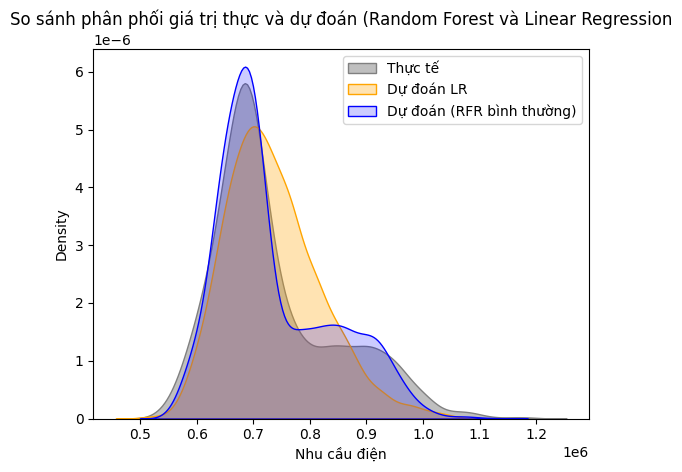

Tạo biểu đồ hoàn tất.


INFO:ML_Project_Logger:Tạo biểu đồ hoàn tất.


In [ ]:
logger.info("Đang tạo biểu đồ so sánh phân phối...")
sns.kdeplot(y_test, label='Thực tế', color='gray', fill=True, alpha=0.5)
sns.kdeplot(y_pred_lr, label='Dự đoán LR', color='orange', fill=True, alpha=0.3)
sns.kdeplot(y_pred_rf, label='Dự đoán (RFR bình thường)', color='blue', fill=True, alpha=0.2)
plt.title("So sánh phân phối giá trị thực và dự đoán (Random Forest và Linear Regression")
plt.xlabel("Nhu cầu điện")
plt.legend()
plt.show()
logger.info("Tạo biểu đồ hoàn tất.")

In [ ]:
logger.info("--- KẾT THÚC PHIÊN LÀM VIỆC ---")

# In nội dung của file log ra màn hình
print("\n--- NỘI DUNG FILE model_training.log ---")
!cat model_training.log

--- KẾT THÚC PHIÊN LÀM VIỆC ---


INFO:ML_Project_Logger:--- KẾT THÚC PHIÊN LÀM VIỆC ---



--- NỘI DUNG FILE model_training.log ---
2025-11-11 14:31:11,493 - ML_Project_Logger - INFO - --- Logger 'ML_Project_Logger' đã được khởi tạo. Bắt đầu phiên làm việc. ---
2025-11-11 14:31:11,517 - ML_Project_Logger - INFO - Đang tải dữ liệu elec từ: https://raw.githubusercontent.com/kynpl0406/elec_prediction/refs/heads/main/elec9.csv
2025-11-11 14:31:11,521 - ML_Project_Logger - INFO - Đang tải dữ liệu weather từ: https://raw.githubusercontent.com/kynpl0406/elec_prediction/refs/heads/main/full_data_weather2.csv
2025-11-11 14:31:12,059 - ML_Project_Logger - INFO - Đã tải dữ liệu thành công!
2025-11-11 14:31:12,068 - ML_Project_Logger - INFO - Shape df_elec ban đầu: (2435, 5)
2025-11-11 14:31:12,080 - ML_Project_Logger - INFO - Shape df_weather ban đầu: (12180, 10)
2025-11-11 14:31:12,439 - ML_Project_Logger - INFO - Đang gộp (merge) df_elec và df_weather...
2025-11-11 14:31:12,509 - ML_Project_Logger - INFO - Shape sau khi gộp: (12175, 14)
2025-11-11 14:31:12,777 - ML_Project_Logger - 